In [1]:
import CT.Models.Unet as Unet
import CT.Models.SAD_NS as SAD_NS
def load_SAD(file_string):
    model_dict = torch.load(file_string)
    model_cnn=Unet.ModernUnetDoubleRegressor_plus(model_dict["config"])
    if model_dict["config"]["PDE"] == "Kolmogorov":
        diffusion_model=SAD_NS.SAD_NS(model_dict["config"], model=model_cnn)
    elif model_dict["config"]["PDE"] == "QG":
        diffusion_model=SAD_QG.SAD_QG(model_dict["config"], model=model_cnn)
    else:
        raise ValueError("PDE Type not recognized")

    diffusion_model.load_state_dict(model_dict["state_dict"])
    return diffusion_model

In [2]:
import torch
import CT.Models.misc as misc
import CT.Inference.Kolmogorov.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAD_NS_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260106_174507-aqhq619n/files/checkpoint_last.p"
SAD_NS = load_SAD(SAD_NS_file_path).to(device)

/state/partition1/job-695270/ipykernel_466972/3427665290.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [3]:
SAD_NS.config

{'model_type': 'ModernUnetDoubleRegressor_plus',
 'input_channels': 2,
 'output_channels': 2,
 'hidden_channels': 64,
 'norm': False,
 'dim_mults': [2, 2, 2],
 'n_blocks': 2,
 'mid_attn': False,
 'is_attn': (False, False, False, False),
 'activation': 'gelu',
 'image_width': 64,
 'image_height': 64,
 'first_embedding_dim': 100,
 'second_embedding_dim': 100,
 'third_embedding_dim': None,
 'save_path': '/scratch/ql2221/CT_models/wandb_data/wandb/run-20260106_174507-aqhq619n/files',
 'save_name': 'model_weights.pt',
 'diffusion_steps': 100,
 'regression_output_dim': 100,
 'regression_target': 'pred_both_noise_level',
 'noise_schedule': 'Cosine',
 'project': 'CT',
 'wandb_run_name': '100_steps',
 'wandb_log_freq': 100,
 'ddp': False,
 'PDE': 'Kolmogorov',
 'file_path': '/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/small_ACDM_training_data.p',
 'subsample': None,
 'train_ratio': 0.95,
 'loader_workers': 1,
 'regression_loss_weight': 0.1,
 'optimization': {'epochs': 1000,
  'lr': 5e-

In [4]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p", weights_only = True)
data = data_dict["data"]/4.44
print(data.shape)

torch.Size([5, 50000, 64, 64])


In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import trange

@torch.no_grad()
def test_sad_ns_regressor_fixed_short(
    SAD_NS,
    classifier_test_data,
    device,
    *,
    s_short_fixed=30,     # fixed short-lag noise level for the entire test
    head_xt=2,            # head predicting s_t (choose 1->reg1, 2->reg2)
    head_short=1,         # head predicting s_short (choose 1->reg1, 2->reg2)
    show_plots=True,
    use_tqdm=True,
    aggregate_short="votes",   # "votes" (argmax counts) or "probs" (mean softmax)
):
    """
    One sweep only:
    - Fix s_short = s_short_fixed for the short-lag frame
    - Sweep s_t over [0, S-1] for the current frame
    - For each s_t, run SAD_NS.model([x_short_noised, x_t_noised], regression_output=True)

    Plots:
    1) Heatmap: rows=true s_t, cols=predicted s_t probability (mean over batch)
    2) Bar chart: aggregated short-head output over the sweep
       - if aggregate_short="votes": sums argmax votes over (s_t sweep x batch)
       - if aggregate_short="probs": sums mean probabilities over s_t sweep
    """

    S = int(SAD_NS.config["diffusion_steps"])
    softmax = nn.Softmax(dim=1)

    x = classifier_test_data.to(device)

    # Accept (B,S,H,W) or (B,S,C,H,W)
    if x.ndim == 4:
        x = x.unsqueeze(2)  # (B,S,1,H,W)
    if x.ndim != 5:
        raise ValueError(f"Expected (B,S,H,W) or (B,S,C,H,W). Got {tuple(x.shape)}")

    B, T_seq, C, H, W = x.shape
    if T_seq < 2:
        raise ValueError(f"Need at least 2 frames in sequence. Got {T_seq}.")

    # Frames: (B,C,H,W)
    x_t = x[:, -1]
    x_short = x[:, -2]

    if not (0 <= int(s_short_fixed) < S):
        raise ValueError(f"s_short_fixed must be in [0, {S-1}]. Got {s_short_fixed}.")

    # Fixed short noise level for all runs
    s_short = torch.full((B,), int(s_short_fixed), dtype=torch.int64, device=device)

    # Output containers
    pred_xt_heatmap = torch.zeros((S, S), dtype=torch.float32)  # row=true s_t, col=pred prob
    short_hist = torch.zeros((S,), dtype=torch.float32)         # aggregated short-head distribution

    it = trange(S, desc="Sweeping x_t noise level (s_t)", disable=not use_tqdm)
    for s_t_true in it:
        s_t = torch.full((B,), int(s_t_true), dtype=torch.int64, device=device)

        # independent noise each step (as in your current implementation)
        eps_t = torch.randn_like(x_t)
        eps_short = torch.randn_like(x_short)

        x_t_noised = SAD_NS._forward_diffusion(x_t, s_t, eps_t)
        x_short_noised = SAD_NS._forward_diffusion(x_short, s_short, eps_short)

        noised_imgs = torch.cat((x_short_noised, x_t_noised), dim=1)

        out = SAD_NS.model(noised_imgs, regression_output=True)
        if not (isinstance(out, (tuple, list)) and len(out) == 3):
            raise RuntimeError("Expected SAD_NS.model(...) -> (pred_img, reg1_logits, reg2_logits).")
        _, reg1_logits, reg2_logits = out

        # --- x_t head heatmap (probabilities) ---
        logits_xt = reg1_logits if head_xt == 1 else reg2_logits
        probs_xt = softmax(logits_xt)                 # (B,S)
        pred_xt_heatmap[s_t_true] = probs_xt.mean(dim=0).detach().cpu()

        # --- short head aggregation over the sweep ---
        logits_short = reg1_logits if head_short == 1 else reg2_logits
        if aggregate_short == "votes":
            preds = logits_short.argmax(dim=1).detach().cpu()  # (B,)
            short_hist += torch.bincount(preds, minlength=S).to(torch.float32)
        elif aggregate_short == "probs":
            probs_short = softmax(logits_short).mean(dim=0).detach().cpu()  # (S,)
            short_hist += probs_short
        else:
            raise ValueError("aggregate_short must be one of {'votes','probs'}")

    if show_plots:
        # Plot 1: x_t heatmap
        plt.figure()
        plt.imshow(pred_xt_heatmap, aspect="auto", origin="lower")
        plt.colorbar(label="Mean probability")
        plt.xlabel("Predicted noise level for x_t")
        plt.ylabel("True noise level for x_t")
        plt.title(f"x_t head distribution (s_short fixed at {s_short_fixed}; input=[short,current])")
        plt.tight_layout()
        plt.show()

        # Plot 2: short-lag bar chart
        plt.figure()
        xs = list(range(S))
        plt.bar(xs, short_hist.numpy())
        plt.axvline(s_short_fixed, linestyle="--")  # should align with dominant bar if model is correct
        plt.xlabel("Predicted noise level for short-lag frame (s_short)")
        plt.ylabel("Aggregated " + ("argmax votes" if aggregate_short == "votes" else "mean probability sum"))
        plt.title(
            f"Short-head aggregated over s_t sweep (true s_short={s_short_fixed})"
        )
        plt.tight_layout()
        plt.show()

    return {
        "pred_xt_heatmap": pred_xt_heatmap,  # (S,S)
        "short_hist": short_hist,            # (S,)
        "s_short_fixed": int(s_short_fixed),
        "aggregate_short": aggregate_short,
    }


/ext3/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import torch

# x: [5, 5000, 64, 64]
data = data[:,::10]/4.44
# 1. Split along dim=1 into 50 chunks of size 100
chunks = data.split(100, dim=1)  # tuple of 50 tensors, each [5,100,64,64]

# 2. Now split batch dimension so each chunk becomes 5 separate tensors
#    producing 250 tensors of shape [1,100,64,64]
chunks = [c[i:i+1] for c in chunks for i in range(c.size(0))]

# 3. Concatenate along the first dimension
out = torch.cat(chunks, dim=0)

print(out.shape)   # [250, 100, 64, 64]

torch.Size([250, 100, 64, 64])


Sweeping x_t noise level (s_t): 100%|██████████| 100/100 [00:04<00:00, 20.46it/s]


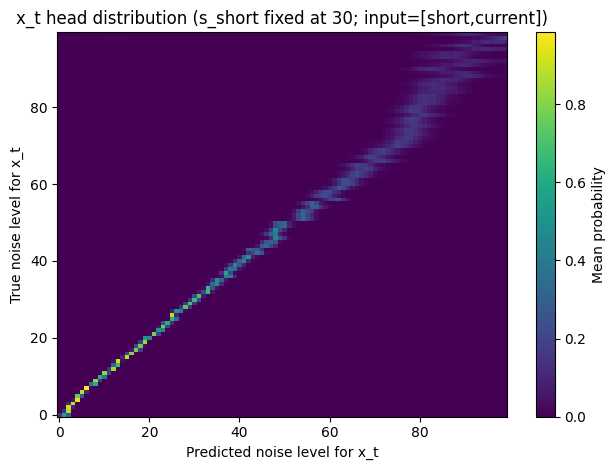

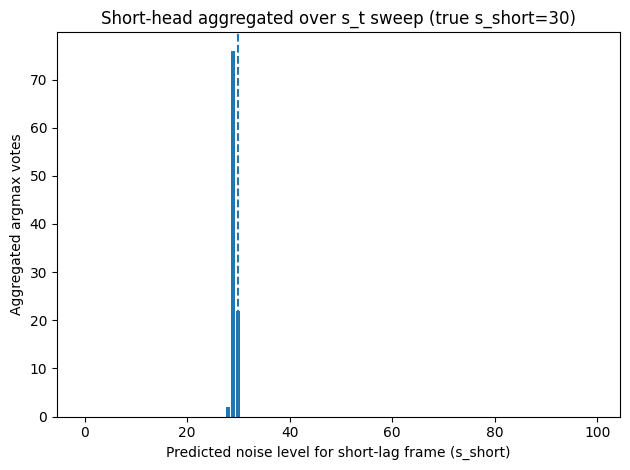

In [7]:
results = test_sad_ns_regressor_fixed_short(
    SAD_NS=SAD_NS,
    classifier_test_data=out[0:1],
    device=device,
)


In [20]:
x = data[0:1].to(device)
x_short_lag = SAD_NS._forward_diffusion(x[:,-6:-5],10)
x_t = SAD_NS._forward_diffusion(x[:,-6:-5],20)
x_in = torch.cat((x_short_lag,x_t), dim = 1)

In [21]:
def denoising_with_refinement(SAD_NS, x):
        pred_s = SAD_NS.model.ratio_class_both(x)
        print(pred_s)
        pred_s_t = pred_s[:,-1]
        pred_s_short_lag = pred_s[:,-2]
        x_t_noised = x[:,-1:]
        x_short_lag_noised = x[:,-2:-1]
        # x_t_noised = SAD_NS._forward_diffusion(x_t, pred_s_t)
        # x_short_lag_noised = SAD_NS._forward_diffusion(x_short_lag, pred_s_short_lag)
        x_in = torch.cat((x_short_lag_noised,x_t_noised), dim = 1)
    
        for i in tqdm(range(pred_s_t-1,pred_s_short_lag-1,-1),desc="Denoising",disable=SAD_NS.silence):
            s = torch.full((x_short_lag.shape[0],), i, dtype=torch.int64, device=x.device)
            noise=torch.randn_like(x_in,device=x.device)
            x_in = SAD_NS._reverse_diffusion_with_guidence(x_in, s, noise)
        for i in tqdm(range(pred_s_short_lag-1,-1,-1),desc="Denoising",disable=SAD_NS.silence):
            s = torch.full((x_short_lag.shape[0],), i, dtype=torch.int64, device=x.device)
            noise=torch.randn_like(x_in,device=x.device)
            x_in = SAD_NS._reverse_diffusion_both(x_in, s, noise)
        return x_in

In [22]:
SAD_NS.eval()
x_tp1 = SAD_NS.denoising_with_refinement(x_in, False)[:,-1:]

In [23]:
error = x_tp1 - x[:,-1:]

In [24]:
x_tp1.max()

tensor(1.0877, device='cuda:0')

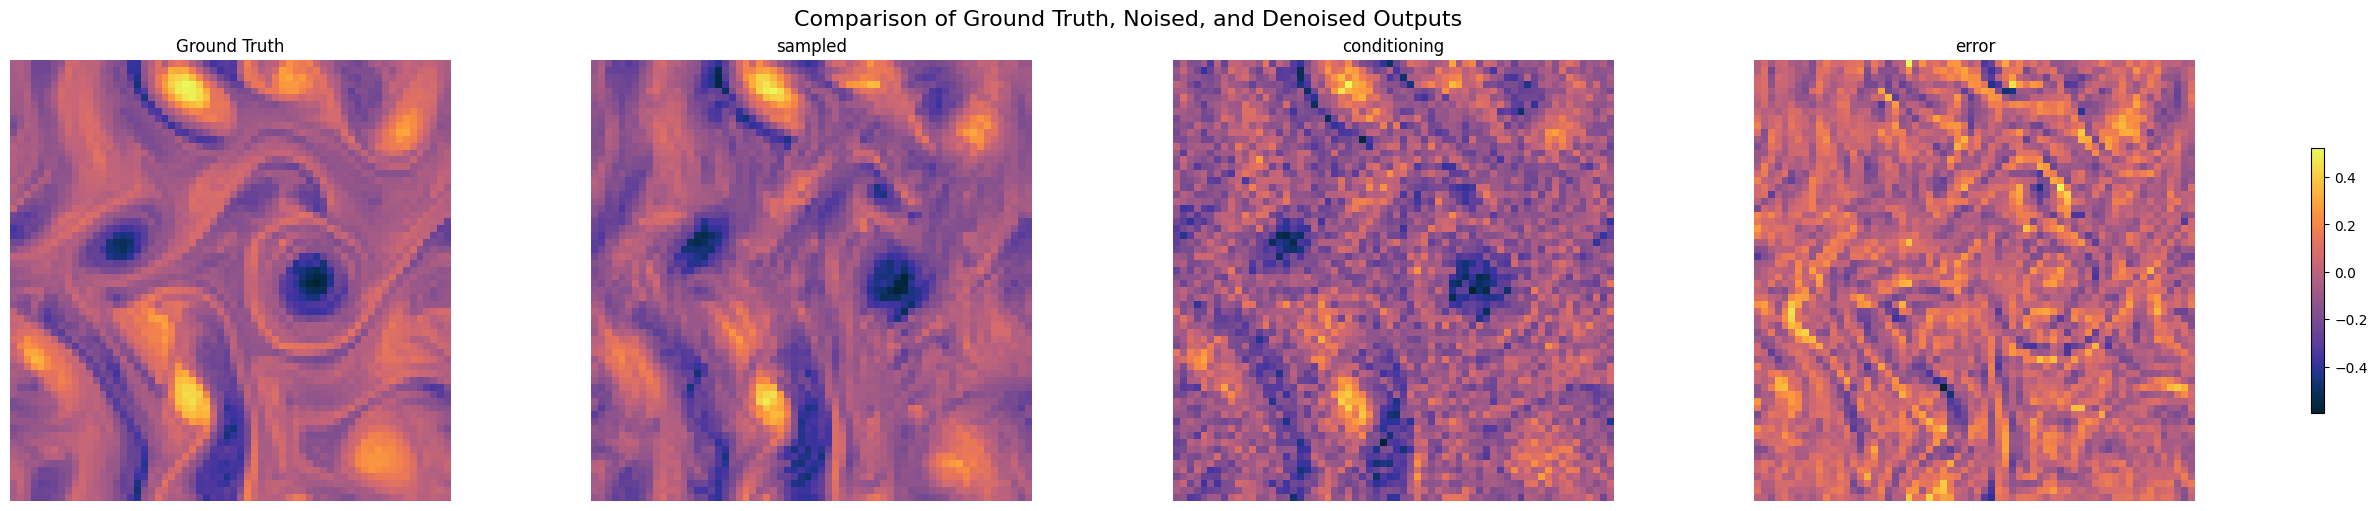

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x[:,-1:],                
    x_tp1,
    x_short_lag,
    error
]
titles = [
    'Ground Truth',
    'sampled',
    'conditioning',
    'error',
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()
